<a href="https://colab.research.google.com/github/worldstar0722/IS4490_FA26/blob/main/module_04_assignment_04_tools_and_skills_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 4: Tool Categories for Business AI
## Database Lookup, File Creation, and Graph Creation with Ollama and LangChain

**Business scenario:** An operations analyst wants an AI assistant that can look up fictional customer records, save approved text as a local file, and turn supplied counts into a chart. The model must choose the capability that matches the request rather than treating every question the same way.

**Learning objectives:** By completing this notebook, you will run and evaluate three provided tools, explain the business purpose and boundary of each tool, observe model selection when several tools are available, build your own bounded database tool by adapting a provided example, and document what you personally tested and verified.

**LangChain's role:** LangChain is the coordination layer between the Ollama language model and the Python functions in this notebook. Its `@tool` decorator turns each function's name, description, and typed parameters into a structured tool definition the model can see; `bind_tools` makes the approved tools available for a request; and LangChain message objects carry the model's proposed tool call and the tool result through the conversation. This matters because it separates the model's decision to request a capability from the application's execution of that capability, making the selected tool, arguments, and result visible for testing.

LangChain helps organize this interaction, but it does not enforce permissions or make a function safe—the Python code and host application must still validate inputs, restrict data and file access, and decide whether a requested tool may run.

**From probabilistic requests to deterministic execution:** Several things can go wrong before, during, or after a tool call: the model may call no tool, select the wrong tool, supply missing or unsupported arguments, request multiple tools, misunderstand a tool result, or produce a confident final answer after a tool returns an error or no match.

The user's natural-language request and the model's interpretation of it are probabilistic; LangChain helps the model express that interpretation as a structured tool name and arguments, but the host application must validate the proposed values against required types, allowlists, ranges, and permissions before execution. Once validated arguments reach a deterministic function—such as a parameterized SQL query or plotting routine—the same inputs should produce the same operation and result. The uncertain part has not disappeared, however: as Module 3 showed, model outputs can vary across runs because generation is probabilistic, and even a low-temperature setting does not guarantee identical behavior across model versions, runtimes, or prompts.

The model may therefore choose **differently** when given the **same** request, which is why business systems should test repeated cases, make failures visible, log the selected tool and arguments, and keep deterministic validation between the model's proposal and the tool's execution.

A **tool** is a Python function the model can request when it needs an external capability. In this notebook:

1. `query_customer_accounts(industry)` uses sql to query customer records from the database.
2. `write_to_file(text, filename)` creates a bounded local text artifact.
3. `create_bar_graph(...)` creates a bounded local chart artifact.
4. **You** will build `query_customers_by_region(region)` by adapting Tool 1.

A **trace** is logging added to the code to allow us to see what happened when the "user" asked a question of the LLM. We want to understand if it called a tool and what happened behind the scenes. In general a trace won't be visible to end users and is only for internal purposes.

**takeaway**

Tools are valuable assets to models to extend an LLMs capabilities. However, to use such tools the model must know what tools are available, choose the correct tool based on the request, format the request in such a way as to use the tool correctly and finally interpret the output of the tool to respond to the user when compelte.

These are still independent, single-tool interactions. You are not building a multistep workflow yet; Module 5 will define sequence, shared state, checks, and stopping conditions.

---
## Setups: 1 - Ollama and LangChain

Use Google Colab or a local Jupyter environment. If Ollama and the required Python packages are already installed, skip the installation cell. If the preferred model is unavailable, use an instructor-approved tool-capable equivalent and document the substitution in your AI-use disclosure.

In [ ]:
# GOOGLE COLAB ONLY: install Ollama and the Python packages.
# Skip this cell in a configured local environment.
!apt-get update -qq
!apt-get install -y zstd
!curl -fsSL https://ollama.com/install.sh | sh
!pip install langchain langchain-ollama matplotlib --quiet

W: https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64/InRelease: Key is stored in legacy trusted.gpg keyring (/etc/apt/trusted.gpg), see the DEPRECATION section in apt-key(8) for details.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  zstd
0 upgraded, 1 newly installed, 0 to remove and 107 not upgraded.
Need to get 644 kB of archives.
After this operation, 1,845 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu noble-updates/main amd64 zstd amd64 1.5.5+dfsg2-2build1.1 [644 kB]
Fetched 644 kB in 1s (937 kB/s)
Selecting previously unselected package zstd.
(Reading database ... 126952 files and directories currently installed.)
Preparing to unpack .../z

In [ ]:
# GOOGLE COLAB ONLY: start Ollama in the notebook environment.
# Skip this cell if `ollama serve` is already running locally.
import subprocess
import time

ollama_process = subprocess.Popen(
    ["ollama", "serve"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL,
)
time.sleep(3)
print("Ollama server start requested.")

Ollama server start requested.


In [ ]:
# Pull the model once. This can take several minutes.
!ollama pull gemma4:12b

In [ ]:
from pathlib import Path
import sqlite3

from langchain_ollama import ChatOllama
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage
from langchain_core.tools import tool
import matplotlib.pyplot as plt

MODEL = "gemma4:12b"
llm = ChatOllama(model=MODEL, temperature=0)

OUTPUT_DIR = Path("module4_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Ready. Using {MODEL} through Ollama and LangChain.")
print(f"Generated files will stay inside: {OUTPUT_DIR.resolve()}")

Ready. Using gemma4:12b through Ollama and LangChain.
Generated files will stay inside: /content/module4_outputs


In [ ]:
# Smoke test: confirm that the model responds before continuing.
response = llm.invoke("In one sentence, explain why a business AI system might need a tool.")
print(response.content)

A business AI system needs tools to bridge the gap between internal reasoning and external action by allowing it to access real-time data, perform complex calculations, and interact with third-party software.


---
## Setups: 2 - Create the Fictional Customer Database

Run this cell to create the database records used by both database tools. It will create 7 customers in the database.

In [ ]:
conn = sqlite3.connect("module4_tool_categories.db")
cursor = conn.cursor()

cursor.execute("DROP TABLE IF EXISTS customers")
cursor.execute(
    '''
    CREATE TABLE customers (
        id INTEGER PRIMARY KEY,
        account_name TEXT,
        industry TEXT,
        annual_revenue INTEGER,
        region TEXT,
        account_owner TEXT
    )
    '''
)

sample_customers = [
    (1, "Precision Parts Co.", "Manufacturing", 4200000, "Midwest", "Sarah Chen"),
    (2, "Summit Steel Works", "Manufacturing", 8100000, "South", "James Okafor"),
    (3, "Valley Fabrications", "Manufacturing", 2900000, "West", "Maria Lopez"),
    (4, "Coastal Logistics", "Logistics", 6500000, "East", "David Park"),
    (5, "TechFlow Systems", "Technology", 11000000, "West", "Rachel Torres"),
    (6, "NovaMed Devices", "Healthcare", 9200000, "East", "Linda Patel"),
    (7, "Heritage Foods", "Food and Beverage", 3400000, "Midwest", "Mark Johnson"),
]

cursor.executemany("INSERT INTO customers VALUES (?, ?, ?, ?, ?, ?)", sample_customers)
conn.commit()



inspect the data in the database table

In [ ]:
rows = cursor.execute(
    "SELECT id, account_name, industry, region FROM customers ORDER BY id"
).fetchall()
for row in rows:
    print(row)

(1, 'Precision Parts Co.', 'Manufacturing', 'Midwest')
(2, 'Summit Steel Works', 'Manufacturing', 'South')
(3, 'Valley Fabrications', 'Manufacturing', 'West')
(4, 'Coastal Logistics', 'Logistics', 'East')
(5, 'TechFlow Systems', 'Technology', 'West')
(6, 'NovaMed Devices', 'Healthcare', 'East')
(7, 'Heritage Foods', 'Food and Beverage', 'Midwest')


---
## Setups: 3 - Ask the Model and Show the Tool Trace

This helper exposes the listed tools to the model, executes at most the first requested tool, and prints the model-visible trace. The host application—not the model—executes the Python function.

In [ ]:
def ask_model(question, tools, system_prompt=None):
    system_prompt = system_prompt or (
        "You are a business AI assistant. Select the single tool that best matches "
        "the user's request. Call no tool when none is needed. Never claim that a "
        "tool ran unless its result is present."
    )
    tool_map = {candidate.name: candidate for candidate in tools}
    llm_with_tools = llm.bind_tools(tools)
    messages = [SystemMessage(content=system_prompt), HumanMessage(content=question)]
    response = llm_with_tools.invoke(messages)

    print(f"Question: {question}")

    if not response.tool_calls:
        print("Tool called: none")
        print(f"Answer: {response.content}\n")
        return {
            "question": question,
            "tool_called": None,
            "arguments": None,
            "tool_result": None,
            "answer": response.content,
        }

    if len(response.tool_calls) > 1:
        print(f"Notice: the model requested {len(response.tool_calls)} tools; only the first will run.")

    call = response.tool_calls[0]
    tool_obj = tool_map[call["name"]]
    result = tool_obj.invoke(call["args"])

    print(f"Tool called: {call['name']}")
    print(f"Arguments: {call['args']}")
    print(f"Tool result: {result}")

    messages.extend(
        [
            response,
            ToolMessage(
                content=str(result),
                tool_call_id=call["id"],
                name=call["name"],
            ),
        ]
    )
    final = llm_with_tools.invoke(messages)
    print(f"Answer: {final.content}\n")

    return {
        "question": question,
        "tool_called": call["name"],
        "arguments": call["args"],
        "tool_result": result,
        "answer": final.content,
    }

---
## Tool 1: Query Customers by Industry

**Business problem:** The AI team has received a request to help sales reps retrieve information about customers from our internal database. The sales reps should not need to know SQL to query a database.

**Solution:** They have chosen to give AI a tool that will query the database. If a sales rep asks the AI a question about customers that is supported the tool can be used.

You can imagine we do NOT allow sales reps to delete data from the database. This is just retrieving data, not updating, inserting or deleting data.

**Study this completed implementation closely.** You will use its structure as boilerplate when you build the region-query tool at the end.

Notice that this tool is simply a function in Python with the **@tool** decorator.

In [ ]:
@tool
def query_customer_accounts(industry: str) -> str:
    '''Look up customer accounts by industry.

    Use for internal customer records filtered by industry.
    Do not use for region searches, file creation, charts, public facts, or recommendations.

    Args:
        industry: One of Manufacturing, Logistics, Technology, Healthcare,
            or Food and Beverage.
    '''
    allowed_industries = {
        value.casefold(): value
        for value in [
            "Manufacturing",
            "Logistics",
            "Technology",
            "Healthcare",
            "Food and Beverage",
        ]
    }
    normalized = industry.strip().casefold()
    if normalized not in allowed_industries:
        return (
            "invalid_input: supported industries are Manufacturing, Logistics, "
            "Technology, Healthcare, and Food and Beverage."
        )

    canonical_industry = allowed_industries[normalized]
    rows = cursor.execute(
        '''
        SELECT id, account_name, industry, region
        FROM customers
        WHERE industry = ?
        ORDER BY id
        LIMIT 10
        ''',
        (canonical_industry,),
    ).fetchall()

    if not rows:
        return f"no_match: no staged accounts found for industry '{canonical_industry}'."

    formatted = [
        {
            "id": row[0],
            "account_name": row[1],
            "industry": row[2],
            "region": row[3],
        }
        for row in rows
    ]
    return f"success: {formatted}"

In [ ]:
# Run both a valid case and a controlled invalid-input case.
industry_success = ask_model(
    "Which customer accounts are in Manufacturing?",
    [query_customer_accounts],
)

# review the trace below.
# a user would just see the "Answer"

Did it work? It should have queried and returned the 3 customer records in the database.

Next, this industry isn't in the database so it shouldn't allow the user to query it.

In [ ]:
industry_fail = ask_model(
    "Which customer accounts are in Aerospace?",
    [query_customer_accounts],
)

Question: Which customer accounts are in Aerospace?
Tool called: none
Answer: I'm sorry, but I don't have access to information for the Aerospace industry. I can, however, look up accounts in Manufacturing, Logistics, Technology, Healthcare, or Food and Beverage.



Did it work?

It wasn't supposed to query because it's not a supported industry.

### 🖊 Reflection after Tool 1

In 3–5 sentences, explain:

- why the request required the database tool rather than the model's memory;
- what arguments and minimum necessary fields appeared in the trace;
- what the invalid-input test shows about the tool's boundary.

> **Your response:**
This request required the database tool because the customer records are stored in a private fictional database and are not part of the model’s memory. The trace used Manufacturing as the industry argument, and the tool was designed to return only the customer ID, account name, industry, and region. The Manufacturing request returned three matching records. For the Aerospace request, the model did not call the tool, showing that it recognized Aerospace as being outside the tool’s supported industries.

---
## Tool 2: Create a Bounded Text File

**Business problem:** Save approved text as a local `.txt` artifact. This is a write action, so the host code restricts the filename and output folder. The tool does not email, publish, or upload the file.

In [ ]:
@tool
def write_to_file(text: str, filename: str) -> str:
    '''Save approved text to a local text file in module4_outputs.

    Use only when the user explicitly asks to save supplied or generated text.
    Do not use for database queries, charts, sending messages, publishing, or sensitive data.

    Args:
        text: The non-sensitive text to save.
        filename: A basename ending in .txt; directory paths are not allowed.
    '''
    safe_name = Path(filename).name
    if safe_name != filename or not safe_name.lower().endswith(".txt"):
        return "invalid_input: filename must be a .txt basename with no directory path."
    if not text.strip():
        return "invalid_input: text cannot be empty."

    destination = OUTPUT_DIR / safe_name
    destination.write_text(text, encoding="utf-8")
    return f"success: wrote {len(text)} characters to {destination}"

In [ ]:
file_trace = ask_model(
    "Write this approved note to review_note.txt: Review all AI-generated artifacts before business use.",
    [write_to_file],
)

Question: Write this approved note to review_note.txt: Review all AI-generated artifacts before business use.
Tool called: write_to_file
Arguments: {'filename': 'review_note.txt', 'text': 'Review all AI-generated artifacts before business use.'}
Tool result: success: wrote 54 characters to module4_outputs/review_note.txt
Answer: The note has been successfully saved to review_note.txt.



Did it work?

Here we check the file to see if the LLM used the tool correctly.

In [ ]:
text_path = OUTPUT_DIR / "review_note.txt"
if text_path.exists():
    print(text_path.read_text(encoding="utf-8"))
else:
    print("Expected file was not created; inspect the tool trace above.")

### 🖊 Reflection after Tool 2

In 3–5 sentences, explain:

- what made the request a file-creation task;
- what external effect the tool produced;
- which code boundary limits where and what it can write;
- what a person must review before using the file.

> **Your response:**
The request explicitly asked the assistant to write approved text to a named text file, so it required the file-creation tool. The tool created review_note.txt inside the module4_outputs directory. The code limits the action by accepting only a filename ending in .txt and by removing directory paths from the filename. Before using the file, a person should verify that the text is accurate, appropriate, and does not contain sensitive information.

---
## Tool 3: Create a Bounded Bar Graph

**Business problem:** Turn user-supplied categories and counts into a PNG chart. The model chooses the tool and structures the arguments; deterministic plotting code creates the artifact.

In [ ]:
@tool
def create_bar_graph(
    x_data: list[str],
    y_data: list[float],
    title: str,
    x_label: str,
    y_label: str,
    filename: str,
) -> str:
    '''Create a bar graph from supplied categories and values.

    Use only when the user explicitly requests a bar chart from supplied data.
    Do not use for database lookup, text files, unsupported chart types, or invented data.

    Args:
        x_data: Category labels for the x-axis.
        y_data: Numeric bar heights corresponding to x_data.
        title: Chart title.
        x_label: X-axis label.
        y_label: Y-axis label.
        filename: A basename ending in .png; directory paths are not allowed.
    '''
    safe_name = Path(filename).name
    if safe_name != filename or not safe_name.lower().endswith(".png"):
        return "invalid_input: filename must be a .png basename with no directory path."
    if not x_data or len(x_data) != len(y_data):
        return "invalid_input: x_data and y_data must be nonempty and have equal lengths."
    if any(value < 0 for value in y_data):
        return "invalid_input: bar values cannot be negative for this inventory example."

    destination = OUTPUT_DIR / safe_name
    plt.figure(figsize=(8, 5))
    plt.bar(x_data, y_data)
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig(destination)
    plt.close()
    return f"success: created bar graph at {destination}"

In [ ]:
graph_trace = ask_model(
    "Create a bar chart of staged T-shirt inventory: Large 324, Medium 21, Small 198. "
    "Label the axes and save it as tshirt_inventory.png.",
    [create_bar_graph],
)

Question: Create a bar chart of staged T-shirt inventory: Large 324, Medium 21, Small 198. Label the axes and save it as tshirt_inventory.png.
Tool called: create_bar_graph
Arguments: {'filename': 'tshirt_inventory.png', 'title': 'T-shirt Inventory by Size', 'x_data': ['Large', 'Medium', 'Small'], 'x_label': 'Size', 'y_data': [324, 21, 198], 'y_label': 'Quantity'}
Tool result: success: created bar graph at module4_outputs/tshirt_inventory.png
Answer: The bar chart of the staged T-shirt inventory has been created and saved as `tshirt_inventory.png`.



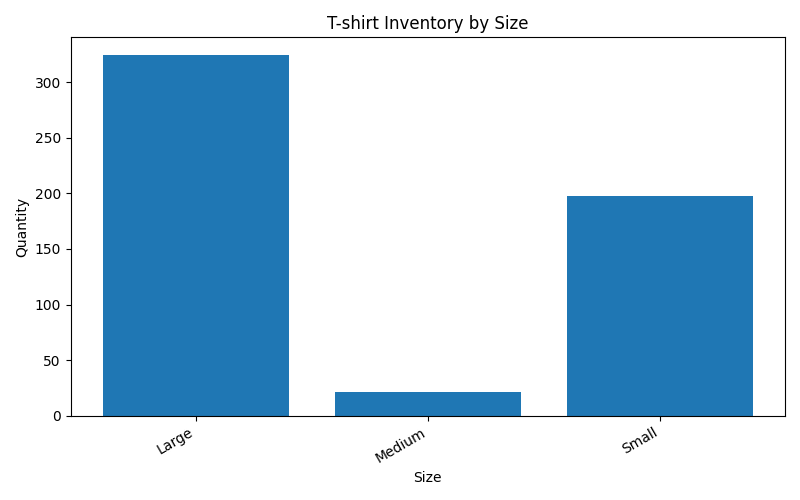

In [ ]:
from IPython.display import Image, display
chart_path = OUTPUT_DIR / "tshirt_inventory.png"
if chart_path.exists():
    display(Image(filename=str(chart_path)))
else:
    print("Expected chart was not created; inspect the tool trace above.")

### 🖊 Reflection after Tool 3

In 3–5 sentences, explain:

- which parts of the chart request became tool arguments;
- why plotting code is more dependable than asking the model to pretend a chart exists;
- one input error the tool handles;
- what you checked in the displayed chart.

> **Your response:**
The category names, inventory counts, chart title, axis labels, and output filename became arguments for the graph tool. Deterministic plotting code creates a real PNG with the supplied data instead of letting the model merely claim that a chart exists. The tool rejects inputs when the category and value lists have different lengths or when a value is negative. I checked that the displayed chart contained the correct categories, values, title, and axis labels.

---
## Part 2: Model Selection with All Provided Tools Available

Earlier, each model call had only one possible tool. That shows whether the tool can run, but it does **not** show whether the model can **select among alternatives**.

Think about it this way, it's easy for the model to choose a hammer if that's the only tool it has available to choose from.

Run the next cell with all three provided tools exposed on every request. Inspect the tool name and arguments in each trace.

We make a list of all the tools the model can select from. When the model needs a tool it can look at this list to see if a tool is available.

In [ ]:
ALL_PROVIDED_TOOLS = [
    query_customer_accounts,
    write_to_file,
    create_bar_graph,
]

This next task should have AI use the query tool.

In [ ]:
selection_database = ask_model(
    "Which customer accounts are in Healthcare?",
    ALL_PROVIDED_TOOLS,
)

Question: Which customer accounts are in Healthcare?
Tool called: query_customer_accounts
Arguments: {'industry': 'Healthcare'}
Tool result: success: [{'id': 6, 'account_name': 'NovaMed Devices', 'industry': 'Healthcare', 'region': 'East'}]
Answer: The customer account in the Healthcare industry is NovaMed Devices (ID: 6).



AI should use the write to file tool.

In [ ]:
selection_file = ask_model(
    "Save this approved reminder to follow_up.txt: Confirm the data before the meeting.",
    ALL_PROVIDED_TOOLS,
)

Question: Save this approved reminder to follow_up.txt: Confirm the data before the meeting.
Tool called: write_to_file
Arguments: {'filename': 'follow_up.txt', 'text': 'Confirm the data before the meeting.'}
Tool result: success: wrote 36 characters to module4_outputs/follow_up.txt
Answer: The reminder has been saved to follow_up.txt.



This next task should cause the AI to use the bar chart tool.

In [ ]:
selection_graph = ask_model(
    "Create a bar chart of open cases: Billing 8, Shipping 5, Product 11. "
    "Save it as open_cases.png.",
    ALL_PROVIDED_TOOLS,
)

Question: Create a bar chart of open cases: Billing 8, Shipping 5, Product 11. Save it as open_cases.png.
Tool called: create_bar_graph
Arguments: {'filename': 'open_cases.png', 'title': 'Open Cases by Category', 'x_data': ['Billing', 'Shipping', 'Product'], 'x_label': 'Category', 'y_data': [8, 5, 11], 'y_label': 'Number of Cases'}
Tool result: success: created bar graph at module4_outputs/open_cases.png
Answer: The bar chart of open cases has been successfully created and saved as `open_cases.png`.



This next prompt request should NOT call any tool. The request is unrelated to a specific tool.

In [ ]:
selection_none = ask_model(
    "Why should a tool call be treated as a request rather than as permission?",
    ALL_PROVIDED_TOOLS,
)

Question: Why should a tool call be treated as a request rather than as permission?
Tool called: none
Answer: In the context of AI systems and software architecture, treating a tool call as a **request** rather than **permission** is a fundamental security and design principle. Here is why:

### 1. The Principle of Least Privilege
If a tool call were treated as "permission," it would imply that the AI (or the system calling the tool) has the inherent authority to execute an action simply because it generated the command. By treating it as a **request**, the system architecture enforces a layer of validation. The AI says, "I would like to perform this action," and the underlying system (or a human-in-the-loop) decides whether that action is safe, valid, and authorized.

### 2. Security and Sandboxing
Treating a tool call as a request allows for a "gatekeeper" mechanism. If an AI generates a command to delete a database or send an email, treating that as a request allows the system to:
*

### 🖊 Reflection on Multi-Tool Selection

In 5–7 sentences:

- report which tool (or no tool) the model selected for each request;
- identify one specific phrase in a tool description that helped distinguish it from the others;
- state whether every choice and argument was appropriate;
- explain why this is still independent tool use rather than a multistep workflow.

> **Your response:**
For the Healthcare request, the model selected query_customer_accounts. It selected write_to_file for the approved reminder and create_bar_graph for the open-cases chart. It correctly selected no tool for the conceptual question about tool calls. The phrase “Use only when the user explicitly asks to save” helped distinguish the file tool from the other tools. In my tests, the selected tools and arguments were appropriate for each request. These were still independent tool uses because each request caused at most one tool to run, with no shared state or required sequence between tools.

---
## Part 3: Build Your Own Customer Query Tool

Your final task is to create `query_customers_by_region(region)`. Use the completed `query_customer_accounts(industry)` implementation as boilerplate, but write and test the new function yourself.

Your tool must:

- accept one typed `region` string;
- support only `East`, `Midwest`, `South`, and `West`;
- use a read-only parameterized SQL query (`WHERE region = ?`);
- return only `id`, `account_name`, `industry`, and `region`;
- order results by `id` and limit results to 10;
- return a controlled `invalid_input`, `no_match`, or `success` result;
- clearly say when it should and should not be used in its docstring.

Do not paste user text into SQL and do not return `annual_revenue` or `account_owner`.

# AI Use Disclosure:
I used ChatGPT to help interpret the Part 3 requirements and adapt the provided industry-query example into a region-query tool. ChatGPT assisted with the function’s docstring, allowed-region validation, parameterized SQL query, controlled result messages, and testing approach. I reviewed the suggested code, ran it in Google Colab, and checked the tool calls, arguments, returned fields, and outputs against the assignment requireme

In [ ]:
# 🔧 TODO: Replace the placeholder body with your own implementation.
# Use query_customer_accounts as a pattern, but adapt every industry-specific
# name, allowed value, query condition, and message for a region search.

@tool
def query_customers_by_region(region: str) -> str:
    """Look up customer accounts by region.

    Use for internal customer records filtered by region.
    Do not use for industry searches, file creation, charts,
    public facts, or requests to modify customer data.

    Args:
        region: One of East, Midwest, South, or West.
    """
    allowed_regions = {
        value.casefold(): value
        for value in [
            "East",
            "Midwest",
            "South",
            "West",
        ]
    }

    normalized = region.strip().casefold()

    if normalized not in allowed_regions:
        return (
            "invalid_input: supported regions are "
            "East, Midwest, South, and West."
        )

    canonical_region = allowed_regions[normalized]

    rows = cursor.execute(
        """
        SELECT id, account_name, industry, region
        FROM customers
        WHERE region = ?
        ORDER BY id
        LIMIT 10
        """,
        (canonical_region,),
    ).fetchall()

    if not rows:
        return (
            f"no_match: no staged accounts found "
            f"for region '{canonical_region}'."
        )

    formatted = [
        {
            "id": row[0],
            "account_name": row[1],
            "industry": row[2],
            "region": row[3],
        }
        for row in rows
    ]

    return f"success: {formatted}"

In [ ]:
region_success = query_customers_by_region.invoke(
    {"region": "West"}
)
print(region_success)

region_invalid = query_customers_by_region.invoke(
    {"region": "Central"}
)
print(region_invalid)

success: [{'id': 3, 'account_name': 'Valley Fabrications', 'industry': 'Manufacturing', 'region': 'West'}, {'id': 5, 'account_name': 'TechFlow Systems', 'industry': 'Technology', 'region': 'West'}]
invalid_input: supported regions are East, Midwest, South, and West.


### Directly Test Your Region Tool

Run one successful case and at least one invalid or no-match case before giving the tool to the model. Keep the outputs visible in your submitted notebook.

In [ ]:
selection_region = ask_model(
    "Which customers are in the region West?",
     [query_customers_by_region],
)

Question: Which customers are in the region West?
Tool called: query_customers_by_region
Arguments: {'region': 'West'}
Tool result: success: [{'id': 3, 'account_name': 'Valley Fabrications', 'industry': 'Manufacturing', 'region': 'West'}, {'id': 5, 'account_name': 'TechFlow Systems', 'industry': 'Technology', 'region': 'West'}]
Answer: The customers in the West region are Valley Fabrications and TechFlow Systems.



In [ ]:
selection_region = ask_model(
    "Which customers are in the region East?",
     [query_customers_by_region],
)

Question: Which customers are in the region East?
Tool called: query_customers_by_region
Arguments: {'region': 'East'}
Tool result: success: [{'id': 4, 'account_name': 'Coastal Logistics', 'industry': 'Logistics', 'region': 'East'}, {'id': 6, 'account_name': 'NovaMed Devices', 'industry': 'Healthcare', 'region': 'East'}]
Answer: The customers in the East region are Coastal Logistics and NovaMed Devices.



### Final Selection Test: All Four Tools

Now expose the three provided tools and your new region tool together. The model should choose your region tool because the request asks for customers by region, not by industry or artifact type.

In [ ]:
ALL_TOOLS = [
    query_customer_accounts,
    write_to_file,
    create_bar_graph,
    query_customers_by_region,
]

region_selection_trace = ask_model(
    "Which customer accounts are in the West region?",
    ALL_TOOLS,
)

Question: Which customer accounts are in the West region?
Tool called: query_customers_by_region
Arguments: {'region': 'West'}
Tool result: success: [{'id': 3, 'account_name': 'Valley Fabrications', 'industry': 'Manufacturing', 'region': 'West'}, {'id': 5, 'account_name': 'TechFlow Systems', 'industry': 'Technology', 'region': 'West'}]
Answer: The customer accounts in the West region are Valley Fabrications and TechFlow Systems.



### 🖊 Short Writeup: Your Region Tool

Write 100–150 words explaining:

- what business question your tool answers;
- its allowed input values and returned fields;
- how its parameterized query and field limit bound access;
- the result of your direct success and invalid/no-match tests;
- whether the final all-tools model call selected it correctly;
- what you personally wrote, checked, or corrected before trusting it.

> **Your response (100–150 words):** My tool answers the business question of which customer accounts belong to a specified region. It accepts only East, Midwest, South, and West and returns the customer ID, account name, industry, and region. The tool uses a parameterized SQL query with WHERE region = ?, preventing user input from being inserted directly into the SQL statement. It also limits access by excluding annual revenue and account owner information, ordering the results by ID, and returning no more than ten records. My direct West test successfully returned Valley Fabrications and TechFlow Systems. The Central test returned a controlled invalid_input message because Central is not an approved region. In the final test with all four tools available, the model correctly selected query_customers_by_region with West as its argument. I checked the allowed inputs, query structure, returned fields, error handling, and final trace before trusting the tool.